# **1. Descripción del Problema**

**Problema:** Clasificación binaria de reseñas de Amazon como positivas (1) o negativas (0)

**Objetivo:** Predecir el sentimiento a partir del texto de la reseña

# **2. Carga y Exploración Inicial (EDA)**

In [66]:
import kagglehub

# Descarga la última versión del dataset de Kaggle
path = kagglehub.dataset_download("bittlingmayer/amazonreviews")

# Imprime la ruta donde se encuentran descargados los archivos del dataset
print("Path to dataset files:", path)

Path to dataset files: C:\Users\salom\.cache\kagglehub\datasets\bittlingmayer\amazonreviews\versions\7


In [67]:
# Como Kagglehub descarga los archivos en una carpeta oculta dentro del caché de usuario, 
# vamos a copiarlos a una ubicación más accesible para su análisis.

import shutil
import os

# Ruta donde Kagglehub guarda los archivos descargados
origen_path = r"C:\Users\salom\.cache\kagglehub\datasets\bittlingmayer\amazonreviews\versions\7"

# Ruta destino donde queremos copiar los archivos
destino_path = r"C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset"

# Copiar todos los archivos del origen al destino
for archivo in os.listdir(origen_path):
    ruta_origen = os.path.join(origen_path, archivo)
    ruta_destino = os.path.join(destino_path, archivo)
    if os.path.isfile(ruta_origen):
        shutil.copy2(ruta_origen, ruta_destino)

print("Archivos copiados exitosamente a:", destino_path)


Archivos copiados exitosamente a: C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset


In [56]:
# Vamos a explorar el contenido de los archivos .bz2 descargados y listar algunas líneas de ejemplo.

import bz2
import os

# Iterar por los archivos .bz2
for archivo in os.listdir(destino_path):
    if archivo.endswith(".bz2"):
        ruta_completa = os.path.join(destino_path, archivo)
        print(f"\n=== Contenido de {archivo} ===")
        
        # Abrir el archivo y leer algunas líneas
        with bz2.open(ruta_completa, "rt", encoding="utf-8") as f:
            for i, linea in enumerate(f):
                print(linea.strip())
                if i >= 4:  # Mostrar solo las primeras 5 líneas
                    break


=== Contenido de test.ft.txt.bz2 ===
__label__2 Great CD: My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I'm in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life's hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing "Who was that singing ?"
__label__2 One of the best game music soundtracks - for a game I didn't really play: Despite the fact that I have only played a small portion of the game, the music I heard (plus the connection to Chrono Trigger which was great as well) led me to purchase the soundtrack, and it remains one of my favorite albums. There is an incredible mix of fun, epic, and emotional songs. Those sad and beautiful tracks I especial

In [68]:
# Ahora procedemos con el análisis de datos utilizando pandas, numpy, matplotlib, seaborn, y nltk.

import bz2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

# Descargar recursos NLTK 
nltk.download('stopwords')
nltk.download('punkt')

# Función para leer y parsear archivos .bz2
def extraer_datos_bz2(file_path, sample_size=50000):

    # Listas para almacenar los datos
    reviews = []
    labels = []
    
    # En el ejercicio inicial se usó un enfoque incorrecto para abrir archivos bz2, por lo tanto, con el try-except se maneja cualquier error.
    try:
        print(f"Intentando abrir: {file_path}")
        print("Archivo abierto correctamente.")
        
        # Abrir el archivo bz2 correctamente
        with bz2.open(file_path, 'rt', encoding='utf-8') as file:
            for i, line in enumerate(file):
                if i >= sample_size:
                    break
                    
                # Mostrar progreso cada 10,000 líneas para monitorear el avance
                if i % 10000 == 0 and i > 0:
                    print(f"Procesadas {i} líneas...")
                
                # Parsear la línea (formato: __label__1 o __label__2)
                if line.startswith('__label__1'):
                    labels.append(1)  # Positivo
                    reviews.append(line[len('__label__1 '):].strip())
                elif line.startswith('__label__2'):
                    labels.append(0)  # Negativo
                    reviews.append(line[len('__label__2 '):].strip())
        
        # Confirmar el número de reseñas procesadas
        print(f"Procesamiento completado: {len(reviews)} reseñas")
        print("\n")
        
    except Exception as e:
        print(f"Error: {e}")
        return None
    
    # Crear DataFrame
    return pd.DataFrame({'review_text': reviews, 'sentiment': labels})

# Mensaje para indicar que se están cargando los datos y que el proceso hasta ahora es correcto
print("\n")
print("Cargando datos con rutas correctas...")
print("\n")

# Definir la ruta base donde se encuentran los archivos
base_path = r"C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset"

# Rutas completas a los archivos de entrenamiento y prueba
train_path = os.path.join(base_path, "train.ft.txt.bz2")
test_path = os.path.join(base_path, "test.ft.txt.bz2")

# Cargar dataset de entrenamiento
df_train = extraer_datos_bz2(train_path, sample_size=50000)

# Cargar dataset de prueba  
df_test = extraer_datos_bz2(test_path, sample_size=10000)

# Verificar que se cargó correctamente el dataset de entrenamiento
if df_train is not None:
    print(f"Distribución de sentimientos en train:")
    print(df_train['sentiment'].value_counts())
else:
    print("Error cargando train")

# Verificar que se cargó correctamente el dataset de prueba
if df_test is not None:
    print(f"Distribución de sentimientos en test:")
    print(df_test['sentiment'].value_counts())
else:
    print("Error cargando test")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\salom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\salom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!




Cargando datos con rutas correctas...


Intentando abrir: C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset\train.ft.txt.bz2
Archivo abierto correctamente.
Procesadas 10000 líneas...
Procesadas 20000 líneas...
Procesadas 30000 líneas...
Procesadas 40000 líneas...
Procesamiento completado: 50000 reseñas


Intentando abrir: C:\Users\salom\Desktop\2025-2\Análisis de Datos\Momento Evaluativo 2\Analisis_de_datos\Evaluación 4\Dataset Amazon Reviews Dataset\test.ft.txt.bz2
Archivo abierto correctamente.
Procesamiento completado: 10000 reseñas


Distribución de sentimientos en train:
sentiment
0    25506
1    24494
Name: count, dtype: int64
Distribución de sentimientos en test:
sentiment
0    5125
1    4875
Name: count, dtype: int64


=== ANÁLISIS DEL DATASET DE ENTRENAMIENTO ===
Dimensiones del dataset de entrenamiento: (50000, 2)


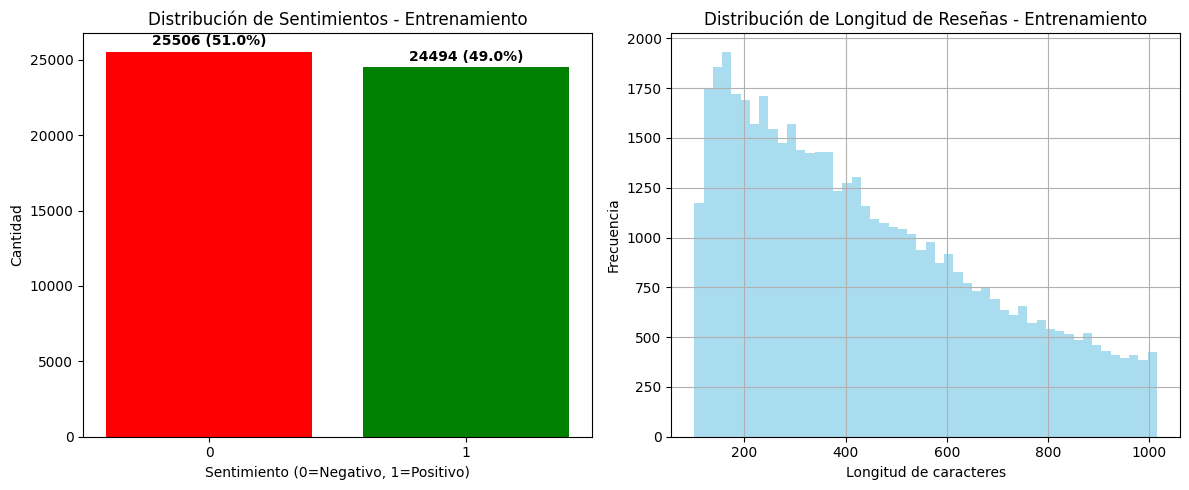

Longitud promedio de reseñas (Entrenamiento): 441.02 caracteres
Longitud máxima (Entrenamiento): 1015 caracteres
Longitud mínima (Entrenamiento): 101 caracteres


=== ANÁLISIS DEL DATASET DE PRUEBA ===
Dimensiones del dataset de prueba: (10000, 2)


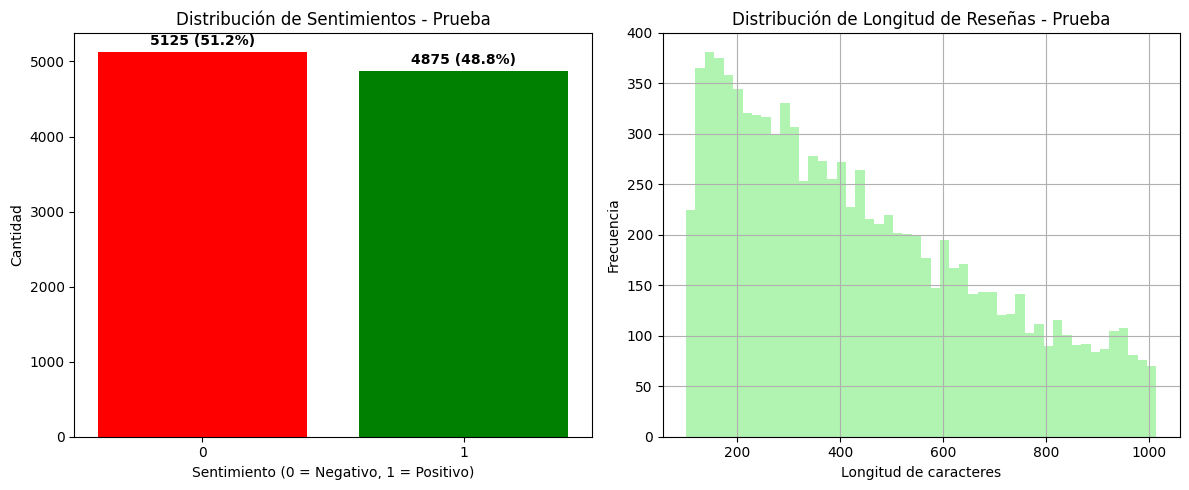

Longitud promedio de reseñas (Prueba): 440.06 caracteres
Longitud máxima (Prueba): 1015 caracteres
Longitud mínima (Prueba): 101 caracteres


In [69]:
import matplotlib.pyplot as plt

# Vamos a analizar ambos datasets por separado: entrenamiento y prueba.

# Análisis del dataset de entrenamiento
print("=== ANÁLISIS DEL DATASET DE ENTRENAMIENTO ===")
print(f"Dimensiones del dataset de entrenamiento: {df_train.shape}")

plt.figure(figsize=(12, 5))

# Subplot 1: Distribución de sentimientos (Entrenamiento)
plt.subplot(1, 2, 1)
sent_counts_train = df_train['sentiment'].value_counts().sort_index()
sent_percent_train = (sent_counts_train / len(df_train)) * 100

bars_train = plt.bar(sent_counts_train.index.astype(str), sent_counts_train.values, color=['red', 'green'])
plt.title('Distribución de Sentimientos - Entrenamiento')
plt.xlabel('Sentimiento (0=Negativo, 1=Positivo)')
plt.ylabel('Cantidad')

# Etiquetas de cantidad y porcentaje
for i, bar in enumerate(bars_train):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height + (len(df_train) * 0.005),
        f"{sent_counts_train.iloc[i]} ({sent_percent_train.iloc[i]:.1f}%)", 
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Subplot 2: Longitud de reseñas (Entrenamiento)
df_train['review_length'] = df_train['review_text'].str.len()
plt.subplot(1, 2, 2)
df_train['review_length'].hist(bins=50, alpha=0.7, color='skyblue')
plt.title('Distribución de Longitud de Reseñas - Entrenamiento')
plt.xlabel('Longitud de caracteres')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas (Entrenamiento)
print(f"Longitud promedio de reseñas (Entrenamiento): {df_train['review_length'].mean():.2f} caracteres")
print(f"Longitud máxima (Entrenamiento): {df_train['review_length'].max()} caracteres")
print(f"Longitud mínima (Entrenamiento): {df_train['review_length'].min()} caracteres")
print("\n")

# --- Análisis del dataset de prueba ---
print("=== ANÁLISIS DEL DATASET DE PRUEBA ===")
print(f"Dimensiones del dataset de prueba: {df_test.shape}")

plt.figure(figsize=(12, 5))

# Subplot 1: Distribución de sentimientos (Prueba)
plt.subplot(1, 2, 1)
sent_counts_test = df_test['sentiment'].value_counts().sort_index()
sent_percent_test = (sent_counts_test / len(df_test)) * 100

bars_test = plt.bar(sent_counts_test.index.astype(str), sent_counts_test.values, color=['red', 'green'])
plt.title('Distribución de Sentimientos - Prueba')
plt.xlabel('Sentimiento (0 = Negativo, 1 = Positivo)')
plt.ylabel('Cantidad')

# Etiquetas con cantidad y porcentaje
for i, bar in enumerate(bars_test):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height + (len(df_test) * 0.005),
        f"{sent_counts_test.iloc[i]} ({sent_percent_test.iloc[i]:.1f}%)", 
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Subplot 2: Longitud de reseñas (Prueba)
df_test['review_length'] = df_test['review_text'].str.len()
plt.subplot(1, 2, 2)
df_test['review_length'].hist(bins=50, alpha=0.7, color='lightgreen')
plt.title('Distribución de Longitud de Reseñas - Prueba')
plt.xlabel('Longitud de caracteres')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas (Prueba)
print(f"Longitud promedio de reseñas (Prueba): {df_test['review_length'].mean():.2f} caracteres")
print(f"Longitud máxima (Prueba): {df_test['review_length'].max()} caracteres")
print(f"Longitud mínima (Prueba): {df_test['review_length'].min()} caracteres")


In [59]:
# Los porcentajes y conteos de sentimientos, así como las estadísticas de longitud de reseñas, muestran un comportamiento muy similar 
# entre los datasets de entrenamiento y prueba. Por lo tanto, no se observan diferencias significativas que puedan afectar el rendimiento del modelo.

# **3. Preprocesamiento de Texto (Optimizado)**

In [71]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Descargar stopwords si no están disponibles
nltk.download('stopwords')

def preprocess_text_optimized(text):
    # Verificar si el texto es una cadena
    if not isinstance(text, str):
        return ""
    # Convertir a minúsculas para estandarizar
    text = text.lower()
    # Eliminar caracteres especiales y números, mantener palabras
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenización simple para mejorar velocidad
    tokens = text.split()
    # Eliminar stopwords y aplicar stemming
    stop_words = set(stopwords.words('english'))
    stemmer = SnowballStemmer("english")
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

# Si el dataset es muy grande, puedes tomar una muestra para desarrollo
x_train = df_train['review_text']
y_train = df_train['sentiment']
x_test = df_test['review_text']
y_test = df_test['sentiment']

# 2. PREPROCESAR POR SEPARADO
print("Preprocesando texto de entrenamiento...")
x_train_cleaned = x_train.apply(preprocess_text_optimized)

print("Preprocesando texto de test...")
x_test_cleaned = x_test.apply(preprocess_text_optimized)

# Verificar resultados del preprocesamiento
print("\nEjemplo de texto original (train):")
print(x_train)
print("\nEjemplo de texto preprocesado (train):")
print(x_train_cleaned)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\salom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Preprocesando texto de entrenamiento...
Preprocesando texto de test...

Ejemplo de texto original (train):
0        Stuning even for the non-gamer: This sound tra...
1        The best soundtrack ever to anything.: I'm rea...
2        Amazing!: This soundtrack is my favorite music...
3        Excellent Soundtrack: I truly like this soundt...
4        Remember, Pull Your Jaw Off The Floor After He...
                               ...                        
49995    From M.E. student: This digital caliper sucks!...
49996    Amazingly nice for the price! Works great!: I ...
49997    Save your money: Not accurate at all. You can ...
49998    great buy...: good price, fast shipping! what ...
49999    Works well for my application...: This product...
Name: review_text, Length: 50000, dtype: object

Ejemplo de texto preprocesado (train):
0        stune even nongam sound track beauti paint sen...
1        best soundtrack ever anyth read lot review say...
2        amaz soundtrack favorit music

# **4. Vectorización TF-IDF**

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Crear el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,   # límite de características para reducir dimensionalidad
    ngram_range=(1, 2),   # considera unigramas y bigramas
    min_df=5,             # ignora términos que aparecen en menos de 5 documentos
    max_df=0.8,           # ignora términos demasiado frecuentes (>80%)
    stop_words='english'  # elimina stopwords del idioma inglés
)

# Ajustar el vectorizador con los datos de entrenamiento y transformar ambos conjuntos
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train_cleaned)
x_test_tfidf = tfidf_vectorizer.transform(x_test_cleaned)

# Mostrar resultados básicos
print(f"Dimensiones de matriz TF-IDF (train): {x_train_tfidf.shape}")
print(f"Dimensiones de matriz TF-IDF (test):  {x_test_tfidf.shape}")

# Mostrar algunas características del vocabulario
print("\nEjemplo de vocabulario:")
print(list(tfidf_vectorizer.get_feature_names_out()[:20]))

Dimensiones de matriz TF-IDF (train): (50000, 10000)
Dimensiones de matriz TF-IDF (test):  (10000, 10000)

Ejemplo de vocabulario:
['abandon', 'abbey', 'abil', 'abl', 'abl make', 'abl play', 'abl read', 'abl use', 'abl watch', 'abomin', 'abort', 'abound', 'abridg', 'abridg version', 'abrupt', 'absenc', 'absent', 'absolut', 'absolut amaz', 'absolut best']


# **5. WordCloud para Análisis Exploratorio**

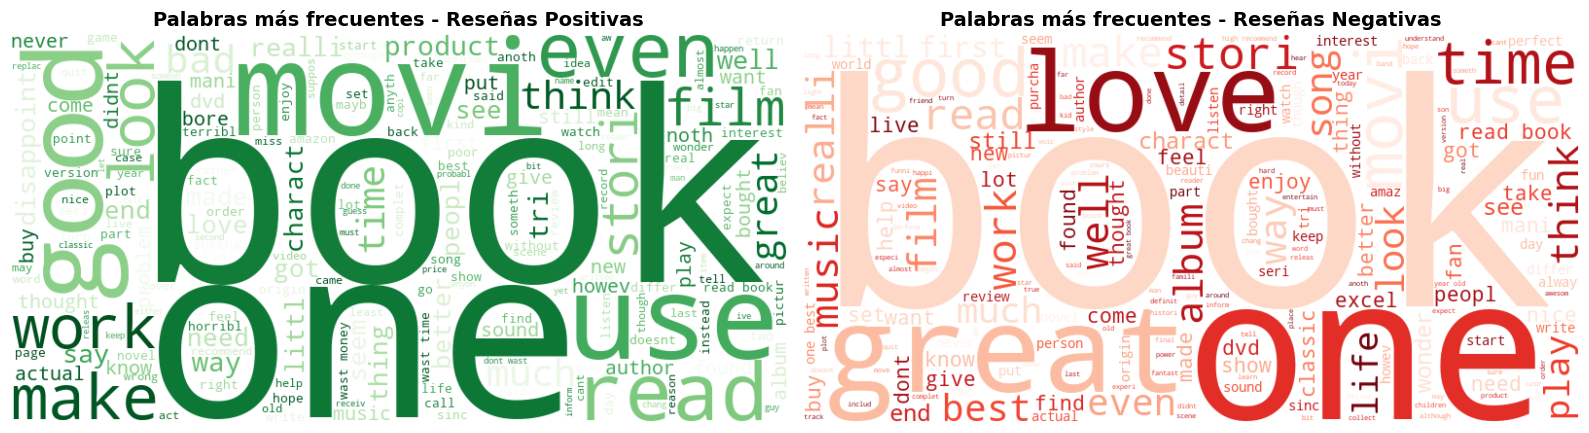

In [73]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Crear DataFrame auxiliar con los textos preprocesados y sus etiquetas
df_cleaned = pd.DataFrame({
    'cleaned_text': x_train_cleaned,
    'sentiment': y_train
})

# Concatenar textos según el sentimiento
texto_positivo = " ".join(df_cleaned[df_cleaned['sentiment'] == 1]['cleaned_text'].astype(str))
texto_negativo = " ".join(df_cleaned[df_cleaned['sentiment'] == 0]['cleaned_text'].astype(str))

# Crear nubes de palabras
wordcloud_pos = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=200
).generate(texto_positivo)

wordcloud_neg = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=200
).generate(texto_negativo)

# Mostrar ambas nubes una al lado de otra
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Palabras más frecuentes - Reseñas Positivas", fontsize=14, fontweight='bold')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Palabras más frecuentes - Reseñas Negativas", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# **6. Entrenamiento de Modelos**

In [74]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import time

# Diccionario de modelos
modelos = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear'),
    "SVM": LinearSVC()
}

# Entrenamiento y almacenamiento de resultados
resultados = {}

for nombre, modelo in modelos.items():
    print(f"\nEntrenando {nombre}...")
    inicio = time.time()
    modelo.fit(x_train_tfidf, y_train)
    duracion = time.time() - inicio
    resultados[nombre] = {"modelo": modelo, "tiempo": duracion}
    print(f"{nombre} entrenado en {duracion:.2f} segundos.")

print("\nEntrenamiento completado.")



Entrenando Naive Bayes...
Naive Bayes entrenado en 0.03 segundos.

Entrenando Logistic Regression...
Logistic Regression entrenado en 0.70 segundos.

Entrenando SVM...
SVM entrenado en 0.83 segundos.

Entrenamiento completado.


# **7. Evaluación Detallada**

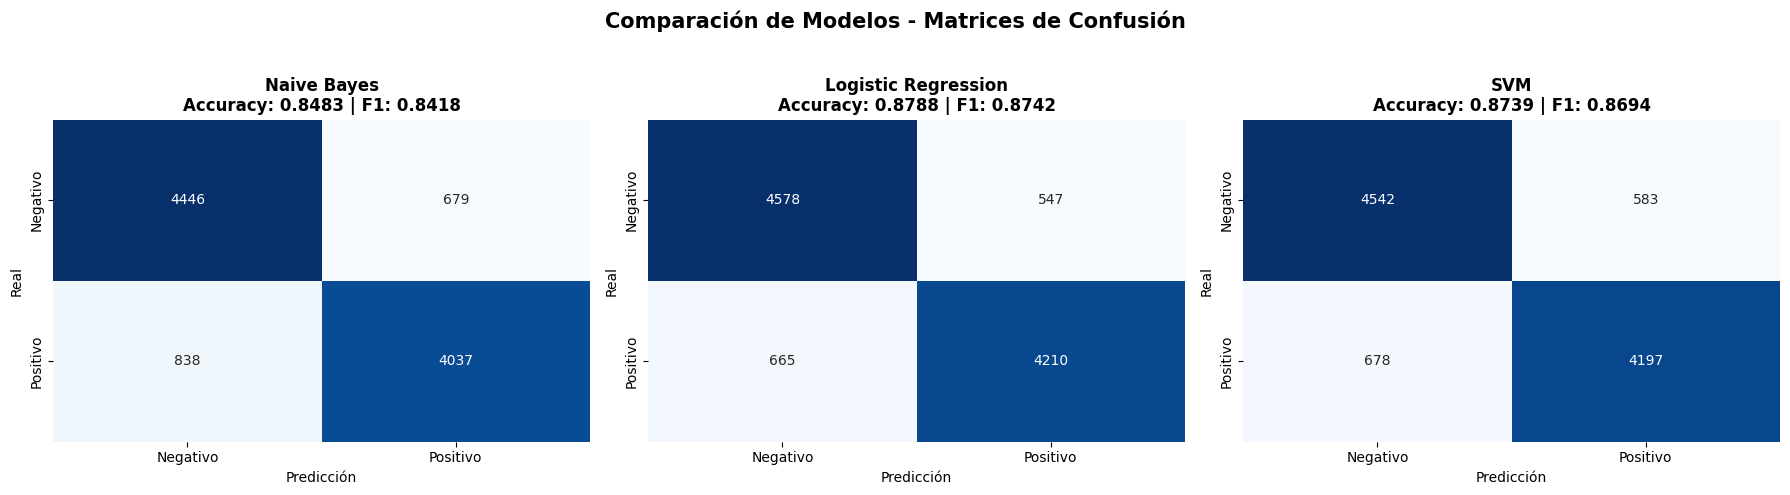


=== RESUMEN DE RESULTADOS ===
                Modelo  Accuracy  F1-Score  Tiempo (s)
0          Naive Bayes    0.8483  0.841831    0.028191
1  Logistic Regression    0.8788  0.874169    0.699395
2                  SVM    0.8739  0.869394    0.826352


In [75]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metricas = []

plt.figure(figsize=(18, 5))

for i, (nombre, info) in enumerate(resultados.items(), 1):
    modelo = info["modelo"]
    y_pred = modelo.predict(x_test_tfidf)
    
    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    metricas.append([nombre, acc, f1, info["tiempo"]])
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Negativo", "Positivo"], yticklabels=["Negativo", "Positivo"])
    plt.title(f"{nombre}\nAccuracy: {acc:.4f} | F1: {f1:.4f}", fontsize=12, fontweight='bold')
    plt.xlabel("Predicción")
    plt.ylabel("Real")

plt.suptitle("Comparación de Modelos - Matrices de Confusión", fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Tabla resumen
df_metricas = pd.DataFrame(metricas, columns=["Modelo", "Accuracy", "F1-Score", "Tiempo (s)"])
print("\n=== RESUMEN DE RESULTADOS ===")
print(df_metricas)


# **8. t-SNE para Visualización**

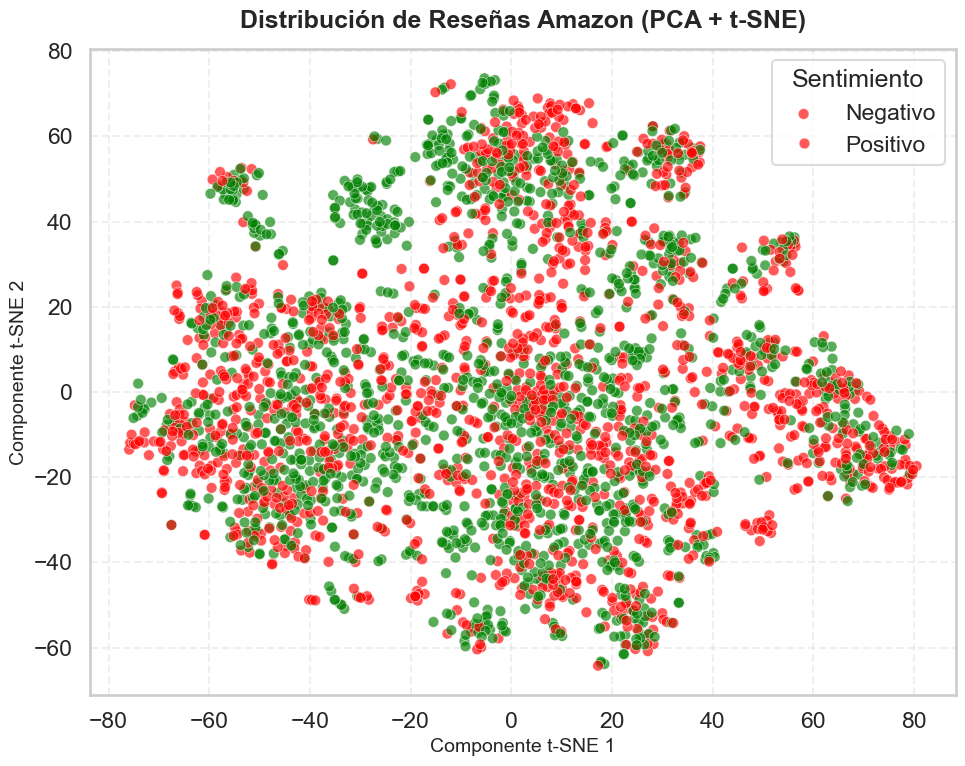

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd

# Reducir dimensiones antes de t-SNE
pca = PCA(n_components=50, random_state=42)
x_pca = pca.fit_transform(x_sample)

# Aplicar t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate=200,
    max_iter=2000,
    random_state=42
)
x_embedded = tsne.fit_transform(x_pca)

# === CONFIGURACIÓN VISUAL ===
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid", context="talk")

# Crear DataFrame para asegurar el orden correcto
df_vis = pd.DataFrame({
    "x1": x_embedded[:, 0],
    "x2": x_embedded[:, 1],
    "sentimiento": y_sample
})

# Paleta fija (Negativo=rojo, Positivo=verde)
palette = {0: "red", 1: "green"}

# Gráfico con orden controlado
scatter = sns.scatterplot(
    data=df_vis,
    x="x1",
    y="x2",
    hue="sentimiento",
    hue_order=[0, 1],  # 🔑 fuerza el orden
    palette=palette,
    alpha=0.65,
    s=60,
    edgecolor="white",
    linewidth=0.5
)

plt.title("Distribución de Reseñas Amazon (PCA + t-SNE)", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Componente t-SNE 1", fontsize=14)
plt.ylabel("Componente t-SNE 2", fontsize=14)
plt.legend(
    title="Sentimiento",
    labels=["Negativo", "Positivo"],  # mantiene el orden visual correcto
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="lightgray"
)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


In [109]:
# === BLOQUE FINAL: CLASIFICACIÓN DE UNA FRASE NUEVA CON LOS 3 MODELOS ===

import pandas as pd

# Diccionario de etiquetas
etiquetas = {0: "Negativa", 1: "Positiva"}

# Ingreso de la frase a evaluar
frase = "This product exceeded my expectations!"

# Preprocesar usando la misma función que se usó en entrenamiento
frase_preprocesada = preprocess_text_optimized(frase)

# Vectorizar la frase con el TF-IDF entrenado
frase_tfidf = tfidf_vectorizer.transform([frase_preprocesada])

# Crear un DataFrame para mostrar resultados
predicciones = []

for nombre, info in resultados.items():
    modelo = info["modelo"]
    pred = modelo.predict(frase_tfidf)[0]
    predicciones.append([nombre, etiquetas[pred]])

# Mostrar resultados
df_pred = pd.DataFrame(predicciones, columns=["Modelo", "Clasificación"])
print("\n=== RESULTADOS DE CLASIFICACIÓN ===")
print(df_pred.to_string(index=False))



=== RESULTADOS DE CLASIFICACIÓN ===
             Modelo Clasificación
        Naive Bayes      Negativa
Logistic Regression      Positiva
                SVM      Negativa
